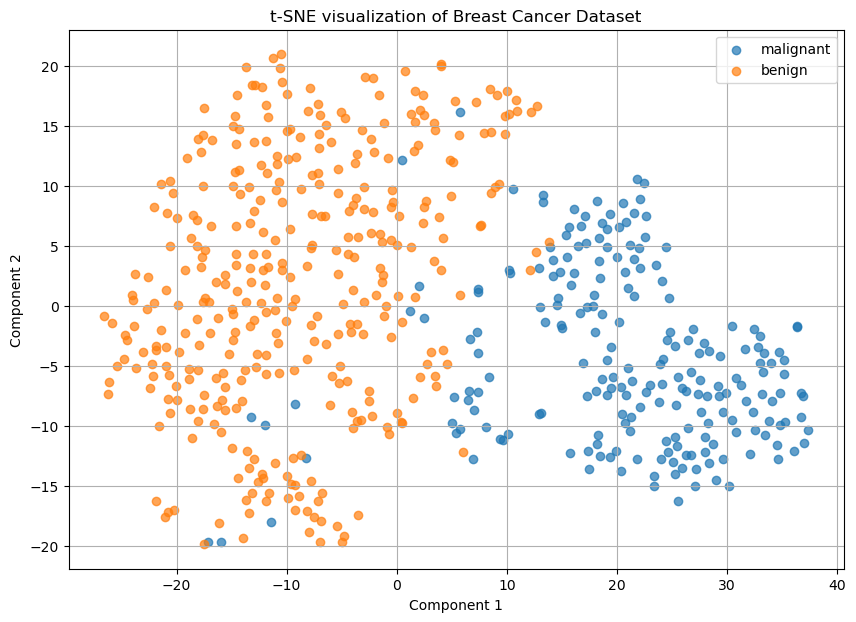

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set the number of threads to 1 for OpenBLAS and MKL
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce dimensions to 50 before t-SNE
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['label'] = y

# Plot the t-SNE result
plt.figure(figsize=(10, 7))
for target, target_name in enumerate(target_names):
    subset = df_tsne[df_tsne['label'] == target]
    plt.scatter(subset['Component 1'], subset['Component 2'], label=target_name, alpha=0.7)

plt.legend()
plt.title('t-SNE visualization of Breast Cancer Dataset')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

C:\Users\abuka\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


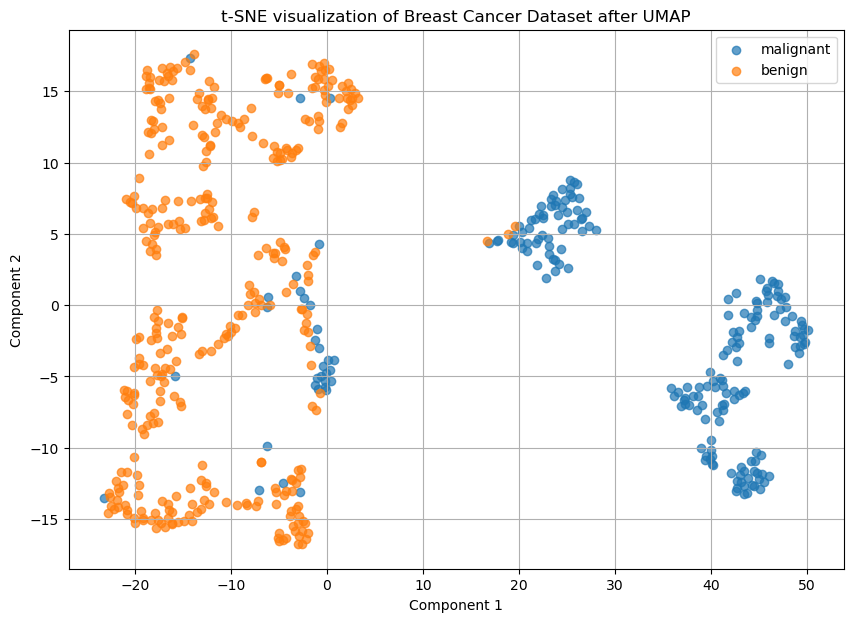

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from sklearn.manifold import TSNE

# Set the number of threads to 1 for OpenBLAS and MKL
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply UMAP to reduce dimensions to 10 before t-SNE
umap = UMAP(n_components=10, random_state=42)
X_umap = umap.fit_transform(X_scaled)

# Apply t-SNE to further reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_umap)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['label'] = y

# Plot the t-SNE result
plt.figure(figsize=(10, 7))
for target, target_name in enumerate(target_names):
    subset = df_tsne[df_tsne['label'] == target]
    plt.scatter(subset['Component 1'], subset['Component 2'], label=target_name, alpha=0.7)

plt.legend()
plt.title('t-SNE visualization of Breast Cancer Dataset after UMAP')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

Accuracy: 0.9707602339181286


C:\Users\abuka\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


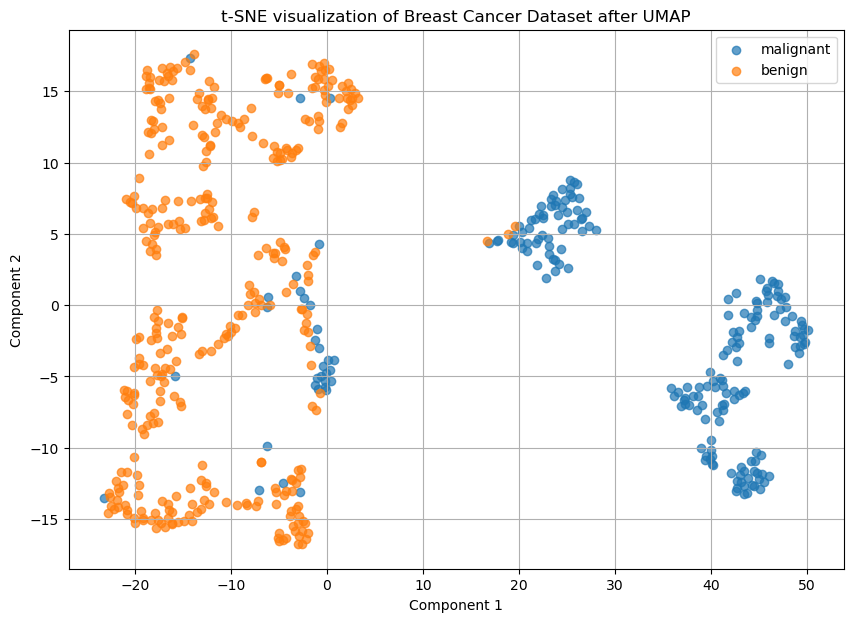

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from umap import UMAP
from sklearn.manifold import TSNE

# Set the number of threads to 1 for OpenBLAS and MKL
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Print the classification report and accuracy
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Apply UMAP to reduce dimensions to 10 before t-SNE
umap = UMAP(n_components=10, random_state=42)
X_umap = umap.fit_transform(X_scaled)

# Apply t-SNE to further reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_umap)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['label'] = y

# Plot the t-SNE result
plt.figure(figsize=(10, 7))
for target, target_name in enumerate(target_names):
    subset = df_tsne[df_tsne['label'] == target]
    plt.scatter(subset['Component 1'], subset['Component 2'], label=target_name, alpha=0.7)

plt.legend()
plt.title('t-SNE visualization of Breast Cancer Dataset after UMAP')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

Accuracy: 0.9707602339181286


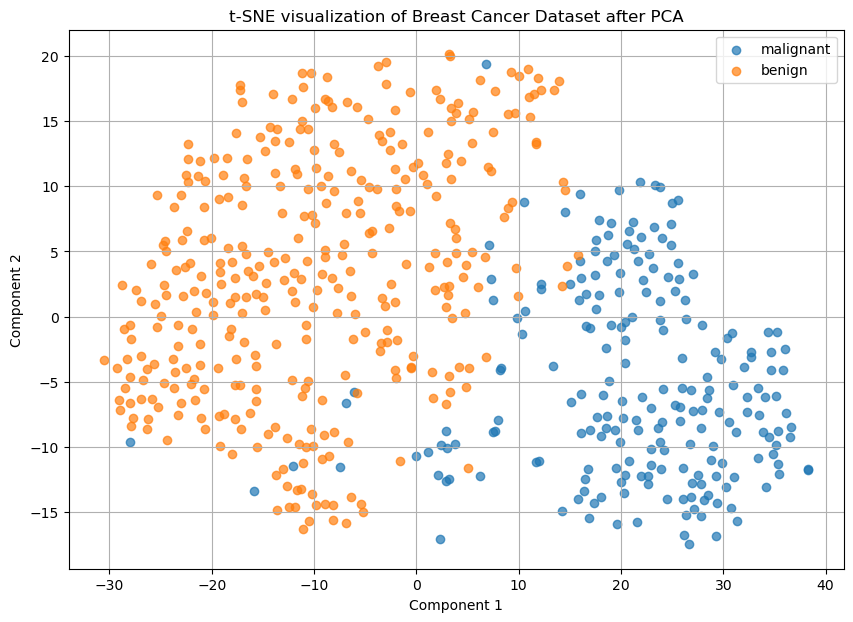

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set the number of threads to 1 for OpenBLAS and MKL
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Print the classification report and accuracy
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Apply PCA to reduce dimensions to 50 before t-SNE
pca = PCA(n_components=9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Apply t-SNE to further reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['label'] = y

# Plot the t-SNE result
plt.figure(figsize=(10, 7))
for target, target_name in enumerate(target_names):
    subset = df_tsne[df_tsne['label'] == target]
    plt.scatter(subset['Component 1'], subset['Component 2'], label=target_name, alpha=0.7)

plt.legend()
plt.title('t-SNE visualization of Breast Cancer Dataset after PCA')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()
